In [4]:
"""
demo.py — Demonstrates the micrograd-like autograd engine and neural net library.
Assumes engine.py (Value class) and nn.py (Neuron, Layer, MLP) are in the same directory.
Run:  python demo.py
"""

import math
import random
from engine import Value
from nn import MLP, Neuron


# ──────────────────────────────────────────────────────────────
# 1.  Basic scalar arithmetic + backprop
# ──────────────────────────────────────────────────────────────
print("=" * 52)
print("1. Scalar autograd")
print("=" * 52)

a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

# f = (a*b + c)^2
f = (a * b + c) ** 2
print(f"a={a.data}, b={b.data}, c={c.data}")
print(f"f = (a*b + c)^2 = {f.data}")

f.grad = 1.0
f.backward()

inner = a.data * b.data + c.data
print(f"df/da = {a.grad:.4f}  (analytic: {2*inner*b.data:.4f})")
print(f"df/db = {b.grad:.4f}  (analytic: {2*inner*a.data:.4f})")
print()


# ──────────────────────────────────────────────────────────────
# 2.  Activation functions
# ──────────────────────────────────────────────────────────────
print("=" * 52)
print("2. Activation functions")
print("=" * 52)

x = Value(1.5)
y = x.tanh()
y.grad = 1.0
y.backward()
expected_grad = 1 - math.tanh(1.5) ** 2
print(f"tanh(1.5)        = {y.data:.6f}")
print(f"d/dx tanh(1.5)   = {x.grad:.6f}  (expected {expected_grad:.6f})")

x2 = Value(-0.5)
r = x2.relu()
r.grad = 1.0
r.backward()
print(f"relu(-0.5)       = {r.data}   (expected 0)")
print(f"d/dx relu(-0.5)  = {x2.grad}   (expected 0)")

x3 = Value(0.5)
e = x3.exp()
e.grad = 1.0
e.backward()
print(f"exp(0.5)         = {e.data:.6f}  (expected {math.exp(0.5):.6f})")
print(f"d/dx exp(0.5)    = {x3.grad:.6f}  (expected {math.exp(0.5):.6f})")
print()


# ──────────────────────────────────────────────────────────────
# 3.  Single neuron
# ──────────────────────────────────────────────────────────────
print("=" * 52)
print("3. Single neuron forward + backward")
print("=" * 52)

random.seed(42)
neuron = Neuron(nin=3, nonlin=True)
x_in = [Value(0.5), Value(-1.0), Value(2.0)]
out = neuron(x_in)
print(f"Neuron : {neuron}")
print(f"Output : {out.data:.6f}")

out.grad = 1.0
out.backward()
print(f"Weight grads : {[round(w.grad, 4) for w in neuron.weights]}")
print(f"Bias grad    : {neuron.bias.grad:.4f}")
print()


# ──────────────────────────────────────────────────────────────
# 4.  MLP architecture overview
# ──────────────────────────────────────────────────────────────
print("=" * 52)
print("4. MLP forward pass")
print("=" * 52)

random.seed(0)
model = MLP(nin=3, nouts=[4, 4, 1])
print(f"Model : {model}")
print(f"Total parameters : {len(model.parameters())}")

sample_input = [0.5, -1.0, 2.0]
prediction = model(sample_input)
print(f"Input  : {sample_input}")
print(f"Output : {prediction.data:.6f}")
print()


# ──────────────────────────────────────────────────────────────
# 5.  Mini training loop — learn XOR
# ──────────────────────────────────────────────────────────────
print("=" * 52)
print("5. Training loop — XOR (labels ±1)")
print("=" * 52)

random.seed(1337)
model = MLP(nin=2, nouts=[8, 8, 1])

xs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
ys = [-1.0,        1.0,        1.0,        -1.0]   # XOR

lr = 0.05

for epoch in range(1, 101):
    # Forward
    preds = [model(x) for x in xs]

    # Mean squared loss: mean( (1 - y*pred)^2 )
    loss = sum(
        ((Value(1.0) - Value(y) * p) ** 2 for y, p in zip(ys, preds)),
        Value(0.0)
    ) * (1.0 / len(xs))

    # Backward
    model.zero_grad()
    loss.grad = 1.0
    loss.backward()

    # SGD update
    for p in model.parameters():
        p.data -= lr * p.grad

    if epoch % 20 == 0:
        acc = sum(1 for y, p in zip(ys, preds) if (p.data > 0) == (y > 0)) / len(ys)
        print(f"Epoch {epoch:3d}  loss={loss.data:.4f}  acc={acc:.0%}")

print()
print("Final predictions:")
for x, y in zip(xs, ys):
    p = model(x)
    predicted = "+1" if p.data > 0 else "-1"
    target    = "+1" if y  > 0 else "-1"
    status    = "OK" if predicted == target else "FAIL"
    print(f"  [{status}]  input={x}  target={target}  got={predicted}  (raw={p.data:.4f})")

1. Scalar autograd
a=2.0, b=-3.0, c=10.0
f = (a*b + c)^2 = 16.0
df/da = -24.0000  (analytic: -24.0000)
df/db = 16.0000  (analytic: 16.0000)

2. Activation functions
tanh(1.5)        = 0.905148
d/dx tanh(1.5)   = 0.180707  (expected 0.180707)
relu(-0.5)       = 0   (expected 0)
d/dx relu(-0.5)  = 0.0   (expected 0)
exp(0.5)         = 1.648721  (expected 1.648721)
d/dx exp(0.5)    = 1.648721  (expected 1.648721)

3. Single neuron forward + backward
Neuron : ReLUNeuron(3)
Output : -0.348782
Weight grads : [0.4392, -0.8784, 1.7567]
Bias grad    : 0.8784

4. MLP forward pass
Model : MLP of [Layer of [ReLUNeuron(3), ReLUNeuron(3), ReLUNeuron(3), ReLUNeuron(3)], Layer of [ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4)], Layer of [LinearNeuron(4)]]
Total parameters : 41
Input  : [0.5, -1.0, 2.0]
Output : -1.135408

5. Training loop — XOR (labels ±1)
Epoch  20  loss=0.8013  acc=75%
Epoch  40  loss=0.5527  acc=100%
Epoch  60  loss=0.2616  acc=100%
Epoch  80  loss=0.0695  acc=100%
Epo

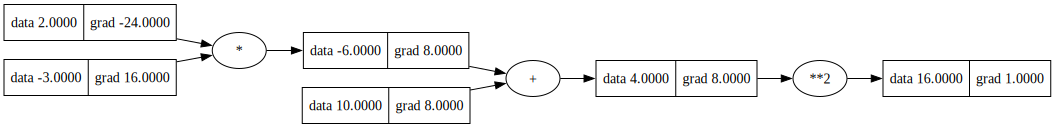

In [3]:
from IPython.display import display
from engine import Value, draw_dot
dot = draw_dot(f)
display(dot)